# Decison Trees

Un **Decision Tree** è un algoritmo di machine learning utilizzato sia per problemi di classificazione che di regressione. È strutturato come un albero in cui ogni nodo rappresenta una condizione su una caratteristica, i rami corrispondono a possibili esiti della condizione, e le foglie rappresentano le decisioni finali (classi o valori).

Ad esempio, come faccio a decidere se uscire di casa o meno?


```
                Meteo
         /         |       \
    Soleggiato  Nuvoloso  Pioggia
       /            \        |
  Umidità           Sì     Vento
  /     \                  /     \
Alta   Bassa            Forte   Debole
  |       |                |       |
 No      Sì               No      Sì
```


## Prevedere chi verrà assunto e chi no

Vediamo ora un piccolo dataset che contiene alcuni dati relativi ad un ufficio di Risorse Umane.

Questo dataset rappresenta un insieme di dati che potrebbe essere utilizzato come input per addestrare un modello di machine learning, come un **albero di decisione**, per prevedere se un candidato viene **assunto** ("Hired").

Ecco una descrizione del dataset in dettaglio:

1. **Caratteristiche (Features)**:
   - **Years Experience** (Anni di esperienza): Un valore numerico che rappresenta l'esperienza lavorativa complessiva del candidato in anni.
   - **Employed?** (Occupato?): Una variabile categorica che indica se il candidato è attualmente impiegato (Y/N).
   - **Previous Employers** (Datori di lavoro precedenti): Un valore numerico che rappresenta il numero di precedenti datori di lavoro.
   - **Level of Education** (Livello di istruzione): Una variabile categorica che specifica il livello educativo del candidato, ad esempio BS (Bachelor's, la triennale), MS (Master's, la magistrale), o PhD (Doctorate, il dottorato di ricerca).
   - **Top-tier school** (Università di prestigio): Una variabile categorica che indica se il candidato ha frequentato un'università di alto livello (Y/N).
   - **Interned** (Stage effettuato): Una variabile categorica che specifica se il candidato ha completato uno stage (Y/N).

2. **Target (Label)**:
   - **Hired** (Assunto): Una variabile binaria che indica se il candidato è stato assunto (Y/N).

In [1]:
import numpy as np
import pandas as pd
from sklearn import tree

file_path = 'dataset_hr_classificazione.xlsx'
df = pd.read_excel(file_path)
df

,Years Experience,Employed?,Previous employers,Level of Education,Top-tier school,Interned,Hired
0,10,Y,4,BS,N,N,Y
1,0,N,0,BS,Y,Y,Y
2,7,N,6,BS,N,N,N
3,2,Y,1,MS,Y,N,Y
4,20,N,2,PhD,Y,N,N
5,0,N,0,PhD,Y,Y,Y
6,5,Y,2,MS,N,Y,Y
7,3,N,1,BS,N,Y,Y
8,15,Y,5,BS,N,N,Y
9,0,N,0,BS,N,N,N


In [2]:
print(df.shape)
df.head()

(13, 7)


,Years Experience,Employed?,Previous employers,Level of Education,Top-tier school,Interned,Hired
0,10,Y,4,BS,N,N,Y
1,0,N,0,BS,Y,Y,Y
2,7,N,6,BS,N,N,N
3,2,Y,1,MS,Y,N,Y
4,20,N,2,PhD,Y,N,N


### Pre-processing

Scikit-learn richiede che tutto sia numerico affinché gli alberi decisionali funzionino. Quindi, mapperemo *Y* e *N* rispettivamente a 1 e 0, e i livelli di istruzione a una scala da 0 a 2. Possiamo farlo perché si tratta di una variabile ordinale!

Nota bene: nel mondo reale, dovresti considerare come gestire dati inattesi o mancanti! Utilizzando il metodo `map()`, sappiamo che otterremo `NaN` per i valori inaspettati.

In [3]:
d = {
    'Y': 1,
    'N': 0
}

df['Hired'] = df['Hired'].map(d)
df['Employed?'] = df['Employed?'].map(d)
df['Top-tier school'] = df['Top-tier school'].map(d)
df['Interned'] = df['Interned'].map(d)

d = {
    'BS': 0,
    'MS': 1,
    'PhD': 2
}

df['Level of Education'] = df['Level of Education'].map(d)

df

,Years Experience,Employed?,Previous employers,Level of Education,Top-tier school,Interned,Hired
0,10,1,4,0,0,0,1
1,0,0,0,0,1,1,1
2,7,0,6,0,0,0,0
3,2,1,1,1,1,0,1
4,20,0,2,2,1,0,0
5,0,0,0,2,1,1,1
6,5,1,2,1,0,1,1
7,3,0,1,0,0,1,1
8,15,1,5,0,0,0,1
9,0,0,0,0,0,0,0


Selezioniamo le features che ci interessano: tutte le colonne, tranne **Hired**

In [4]:
features = list(df.columns[:6])
features

['Years Experience',
 'Employed?',
 'Previous employers',
 'Level of Education',
 'Top-tier school',
 'Interned']

### Costruzione del modello

Come sempre costruiamo l'albero decisionale.

In [5]:
y = df["Hired"]
X = df[features]
clf = tree.DecisionTreeClassifier()
clf = clf.fit(X,y)

E ora lo facciammo vedere!

Per leggere questo albero decisionale, ogni condizione si dirama a sinistra per "vero" e a destra per "falso". Quando si arriva a un valore, l'array `value` rappresenta quanti campioni appartengono a ciascun valore target. Ad esempio, `value = [0. 5.]` significa che ci sono 0 "non assunzioni" e 5 "assunzioni" nel punto raggiunto. Invece, `value = [3. 0.]` significa 3 "non assunzioni" e 0 "assunzioni".

`Interned <= 0.5` invece nel nostro caso va letto come se `Interned=0`. Se è `False`, questo vuol dire che `Interned=1`.

[Text(0.7142857142857143, 0.9, 'Employed? <= 0.5\ngini = 0.426\nsamples = 13\nvalue = [4, 9]'),
 Text(0.5714285714285714, 0.7, 'Interned <= 0.5\ngini = 0.5\nsamples = 8\nvalue = [4, 4]'),
 Text(0.6428571428571428, 0.8, 'True  '),
 Text(0.42857142857142855, 0.5, 'Years Experience <= 0.5\ngini = 0.32\nsamples = 5\nvalue = [4, 1]'),
 Text(0.2857142857142857, 0.3, 'Level of Education <= 1.0\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.14285714285714285, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.42857142857142855, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.5714285714285714, 0.3, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.7142857142857143, 0.5, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.8571428571428571, 0.7, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.7857142857142857, 0.8, '  False')]

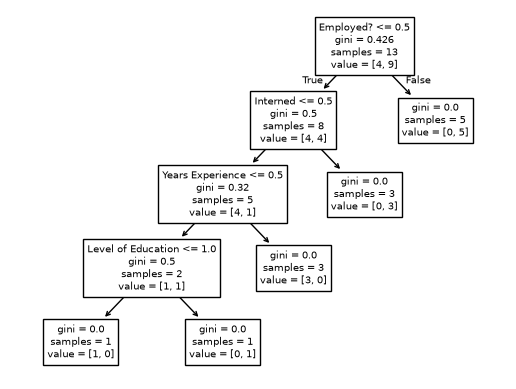

In [6]:
tree.plot_tree(clf,feature_names=features)

Quando leggi il **valore di Gini** su un albero decisionale, rappresenta il grado di impurità del nodo in quel punto:

- **Gini vicino a 0**: il nodo è quasi puro, ovvero la maggior parte dei campioni appartiene a una sola classe.  
- **Gini più alto**: il nodo è più misto, con campioni distribuiti tra più classi.

Nel nostro caso:

- **Gini = 0.0**: Tutti i campioni appartengono a una sola classe (es. 100% "assunzioni").  
- **Gini = 0.5** (in un problema binario): Le classi sono equamente distribuite (es. 50% "assunzioni" e 50% "non assunzioni").  

Il valore di Gini ti aiuta a capire quanto il nodo separa bene i dati. Più è basso, migliore è la separazione.

## Ensemble learning: utilizzare una "random forest"

Puoi provare a usare un **decision tree** per classificare o fare previsioni: il modello è semplice, facile da leggere e interpretare. Ogni nodo rappresenta una decisione basata su una caratteristica, e puoi stampare l'intero albero per visualizzare il flusso delle decisioni.

Tuttavia, con una **random forest**, il funzionamento di base è identico (un insieme di alberi decisionali), ma il modello è molto più performante. La random forest costruisce molti alberi decisionali su campioni casuali dei dati e combina i loro risultati (tramite maggioranza per la classificazione o media per la regressione). Questo riduce l'**overfitting**, migliorando l'accuratezza e la generalizzazione sui dati mai visti.

L'unico svantaggio è che non puoi stampare e leggere facilmente una random forest, poiché è composta da centinaia o migliaia di alberi. In cambio, ottieni però previsioni più robuste e affidabili.

In questo caso, utilizziamo una foresta formata da 10 estimatori (10 alberi che "votano" il risultato)

In [7]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=10)
clf = clf.fit(X, y)

clf

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [8]:
nuovi_assunti = pd.read_excel('nuovi_assunti.xlsx')
nuovi_assunti

,Years Experience,Employed?,Previous employers,Level of Education,Top-tier school,Interned
0,10,1,4,0,0,0
1,2,0,2,0,2,0
2,2,0,2,0,2,1


In [9]:
clf.predict(nuovi_assunti)

array([1, 0, 1])

## Attività

Anche in questo caso, puoi provare a fare esperimenti con un dataset più complesso che trovi qua: [IBM employee attrition](https://github.com/nelson-wu/employee-attrition-ml/raw/refs/heads/master/WA_Fn-UseC_-HR-Employee-Attrition.csv).

Questo dataset contiene dati relativi ai dipendenti di un'azienda e può essere utilizzato per analizzare e prevedere fenomeni come il turnover dei dipendenti (attrition).

Prova ad esercitarti con il workflow completo, utilizzando sia il `DecisionTreeClassifier` che il `RandomForestClassifier`. Come metrica utilizza l'accuracy, con la funzione che ti ho preparato qua sotto.

In [10]:
from sklearn.metrics import accuracy_score

Y   = [0,1,0,0,1]
Yp  = [0,0,0,0,1]

accuracy_score(Y,Yp)

0.8